In [4]:
import ollama
import base64
import httpx
from pathlib import Path

def encode_image_to_base64(image_path: str) -> str:
    """Encode a local image file to base64 string."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def encode_image_from_url(image_url: str) -> str:
    """Download and encode an image from URL to base64 string."""
    response = httpx.get(image_url)
    return base64.b64encode(response.content).decode("utf-8")

def analyze_physics_problem(image_source: str, 
                            is_url: bool = False, 
                            extra_question: str = None):
    """
    Analyze a high school physics problem from an image using Ollama vision model.
    
    Args:
        image_source: Path to local image or URL
        is_url: Set True if image_source is a URL
        extra_question: Optional specific question about the problem
    """
    
    # Encode image
    if is_url:
        print(f"📥 Downloading image from URL...")
        image_data = encode_image_from_url(image_source)
    else:
        print(f"📂 Loading image from local path...")
        image_data = encode_image_to_base64(image_source)
    
    # System prompt for physics tutor
    system_prompt = """You are an expert high school physics tutor. 
    When given an image of a physics problem or assignment:
    1. Carefully analyze all visual elements (diagrams, graphs, equations, figures)
    2. Identify the physics concepts and topics involved
    3. Extract all given information, variables, and unknowns
    4. Provide a clear, step-by-step solution
    5. Explain the physics principles used
    6. Show all calculations with proper units
    7. State the final answer clearly
    8. Anwer with thai language only
    Use clear formatting with sections for: Problem Understanding, Given Information, 
    Physics Concepts, Solution Steps, and Final Answer."""
    
    # User prompt
    if extra_question:
        user_prompt = f"""Please analyze this high school physics assignment image and solve the problem.
        
Additional question: {extra_question}

Provide a complete and detailed solution."""
    else:
        user_prompt = """Please analyze this high school physics assignment image and solve the problem.
        
Identify what type of physics problem this is, extract all relevant information from the image,
and provide a complete step-by-step solution with explanations."""

    print(f"\n🔬 Model: qwen2.5:7b (Vision)")
    print(f"📚 Analyzing physics problem...\n")
    print("=" * 60)
    
    # Call Ollama with vision model
    response = ollama.chat(
        model="qwen3.5:397b-cloud",
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": user_prompt,
                "images": [image_data]  # Pass base64 encoded image
            }
        ],
        options={
            "temperature": 0.3,      # Lower temperature for more precise answers
            "top_p": 0.9,
            "num_predict": 2048,     # Allow long responses for detailed solutions
        }
    )
    
    answer = response["message"]["content"]
    
    print(answer)
    print("=" * 60)
    
    return answer

# ── EXPERIMENT SECTION ──────────────────────────────────────────

# Example 1: Analyze from a local image file
# Uncomment and set your image path:
# image_path = "physics_problem.jpg"
# result = analyze_physics_problem(image_path, is_url=False)

# Example 2: Analyze from a URL
# Uncomment and set your image URL:
# image_url = "https://example.com/physics_problem.png"
# result = analyze_physics_problem(image_url, is_url=True)

# Example 3: With a specific follow-up question
# result = analyze_physics_problem(
#     image_path,
#     is_url=False,
#     extra_question="What formula should I use and why?"
# )

# ── DEMO with a sample physics problem image from the web ───────
demo_path= "image2.png"

print("🚀 Starting Physics Problem Analyzer Experiment")
print("=" * 60)
print(f"Using demo image: Pendulum Physics Problem")

result = analyze_physics_problem(demo_path, is_url=False)

print("\n✅ Experiment Complete!")
print(f"Response length: {len(result)} characters")

🚀 Starting Physics Problem Analyzer Experiment
Using demo image: Pendulum Physics Problem
📂 Loading image from local path...

🔬 Model: qwen2.5:7b (Vision)
📚 Analyzing physics problem...

นี่คือคำวิเคราะห์และวิธีทำโจทย์ฟิสิกส์ทั้ง 3 ข้อจากภาพที่คุณให้มาครับ

---

### **โจทย์ข้อที่ 4: ระบบมวลติดสปริง (Simple Harmonic Motion)**

**1. วิเคราะห์ปัญหา (Problem Understanding):**
โจทย์เกี่ยวกับการเคลื่อนที่แบบฮาร์มอนิกอย่างง่าย (SHM) ของมวลติดสปริง เราต้องหาขนาดของความเร่ง ($a$) ที่ตำแหน่งหนึ่ง โดยทราบแอมพลิจูดและความเร็วที่อีกตำแหน่งหนึ่ง

**2. ข้อมูลที่กำหนด (Given Information):**
*   แอมพลิจูด ($A$) = 5 เซนติเมตร = 0.05 เมตร
*   ตำแหน่งที่วัดความเร็ว ($x_1$) = 3 เซนติเมตร = 0.03 เมตร (ห่างจากจุดสมดุล)
*   ความเร็วที่ตำแหน่ง $x_1$ ($v$) = $\frac{4}{\pi}$ (หน่วยในโจทย์เขียนแปลกๆ แต่จากตัวเลือกคำตอบ สันนิษฐานว่าอาจจะเป็นหน่วยที่ทำให้คำตอบออกมาเป็น 0.32)
*   ต้องการหา: ความเร่ง ($a$) ที่ตำแหน่ง $x_1$ (3 ซม.)

**3. แนวคิดฟิสิกส์ (Physics Concepts):**
*   สูตรความสัมพันธ์ระหว่างความเร็วและตำแหน่ง

In [6]:
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage

# Reuse the encode_image_to_base64 function and demo_path from the previous cell
image_base64 = encode_image_to_base64(demo_path)

# Initialize the LangChain ChatOllama model
# (Ensure you are using a vision-capable model like qwen2.5:7b or llava)
llm = ChatOllama(model="qwen3.5:397b-cloud", temperature=0.3)

# Construct the multimodal message
messages = [
    HumanMessage(
        content=[
            {"type": "text", "text": "Please OCR thai text and describe the content of this image."},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_base64}"}}
        ]
    )
]

# Invoke the model and print the response
langchain_response = llm.invoke(messages)
print(langchain_response.content)

Based on the image provided, here is the OCR text and a description of the content.

### **OCR Text (Thai)**

**4.** นักเรียนทำการทดลองระบบมวลติดสปริง โดยเริ่มดึงนักเรียนยืดสปริงออกจากตำแหน่งสมดุล 5 เซนติเมตรแล้วปล่อย วัดความเร็วได้ได้ $\frac{4}{\pi}$ เซิรต์ด ที่ตำแหน่งห่างจากจุดสมดุล 3 เซนติเมตร จะมีอัตราเร็วที่เมตรต่อวินาที
1. 0.16
2. $0.16\pi$
3. **0.32** (Text in red)
4. $0.32\pi$
5. $0.32\pi^2$

**5.** พิจารณากราฟความเร็วกับเวลาของระบบการสั่นอย่างง่ายด้านล่างล่าง
[Graph showing velocity $v(m/s)$ vs time $t(s)$. Wave oscillates between $10\pi$ and $-10\pi$. X-axis markers include $\frac{1}{2}, \pi, \frac{3}{2}, 2\pi$.]
ข้อใดเป็นสมการความเร่งกับเวลาของระบบ
1. $a(t) = 20 \sin(2t)$
2. **$a(t) = -20 \sin(2t)$** (Text in red)
3. $a(t) = 20\pi \sin(2t + \frac{\pi}{2})$
4. $a(t) = 20\pi^2 \sin(2\pi t)$
5. $a(t) = -20\pi^2 \sin(2\pi t + \frac{\pi}{2})$

**6.** การทดลองการสั่นของมวลติดสปริงขนาด 10 กิโลกรัม สามารถแสดงกราฟตำแหน่งกับเวลาได้ดังรูป
[Graph showing position $x(cm)$ vs time $t(s)$.

In [7]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model=ChatOllama(model="qwen3.5:397b-cloud", temperature=0.3),
    tools=[],  # Add your tools here
    system_prompt="You are a helpful assistant.",
    checkpointer=InMemorySaver(),  # Handles conversation memory
)

# Use with a thread_id to maintain conversation state
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Hello!"}]},
    {"configurable": {"thread_id": "conversation_1"}}
)

print(response)

{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='337a67aa-8c03-4080-b1a0-0a21593c4c2d'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'qwen3.5:397b-cloud', 'remote_model': 'qwen3.5:397b', 'remote_host': 'https://ollama.com:443', 'created_at': '2026-02-28T16:11:51.74796877Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 4411712709, 'prompt_eval_count': 23, 'eval_count': 223}, id='lc_run--019ca505-329c-7b52-b01b-396c90d4f6ba-0', tool_calls=[], invalid_tool_calls=[])]}


In [9]:
agent.invoke({"messages": [{"role": "user", "content": "what you can do with langchain ecsystem?"}]},
    {"configurable": {"thread_id": "conversation_1"}})

{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='337a67aa-8c03-4080-b1a0-0a21593c4c2d'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'qwen3.5:397b-cloud', 'remote_model': 'qwen3.5:397b', 'remote_host': 'https://ollama.com:443', 'created_at': '2026-02-28T16:11:51.74796877Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 4411712709, 'prompt_eval_count': 23, 'eval_count': 223}, id='lc_run--019ca505-329c-7b52-b01b-396c90d4f6ba-0', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what you can do with langchain ecsystem?', additional_kwargs={}, response_metadata={}, id='1153c061-79ac-4616-8903-5a8f7f5efe79'),
  AIMessage(content="The **LangChain ecosystem** is a powerful framework designed to simplify the development of applications powered by large language models (LLMs). It provides tools and abstractions that he

{'messages': [HumanMessage(content=[{'type': 'text', 'text': 'อธิบายมโนทัศน์ในการเรียนรู้ของโจทย์ที่อยู่ในรูป และถ้านักเรียนตอบผิดแสดงความเข้าใจผิดอย่างไรได้บ้า่ง'}, {'type': 'image_url', 'image_url': {'url': ''}}], additional_kwargs={}, response_metadata={}, id='a861de2c-3952-4ec2-b344-8429740d5629'), AIMessage(content='นี่คือการวิเคราะห์โจทย์ฟิสิกส์เรื่องการเคลื่อนที่แบบฮาร์มอนิกอย่างง่าย (Simple Harmonic Motion) จากภาพที่คุณให้มาครับ\n\n### 1. ความเข้าใจโจทย์ (Problem Understanding)\nโจทย์กำหนดสถานการณ์การทดลองการสั่นของมวลติดสปริง โดยให้ข้อมูลสำคัญ 2 ส่วนคือ:\n1.  **ข้อมูลตัวเลข:** มวล ($m$) มีขนาด 10 กิโลกรัม\n2.  **ข้อมูลจากกราฟ:** กราฟแสดงความสัมพันธ์ระหว่างตำแหน่ง ($x$) กับเวลา ($t$) ซึ่งเป็นรูปคลื่นไซน์ (Sinusoidal wave)\n\n**สิ่งที่โจทย์ถาม:** ให้หา **อัตราเร็วเชิงมุม ($\\omega$)** และ **ค่าคงที่ของสปริง ($k$)** ที่ถูกต้อง จากตัวเลือกในตาราง\n\n---\n\n### 2. ข้อมูลที่กำหนดให้ (Given Information)\nจากการอ่านกราฟและข้อความในโจทย์ เราสามารถสกัดข้อมูลได้ดังนี้:\n*   **มวล ($m$):*
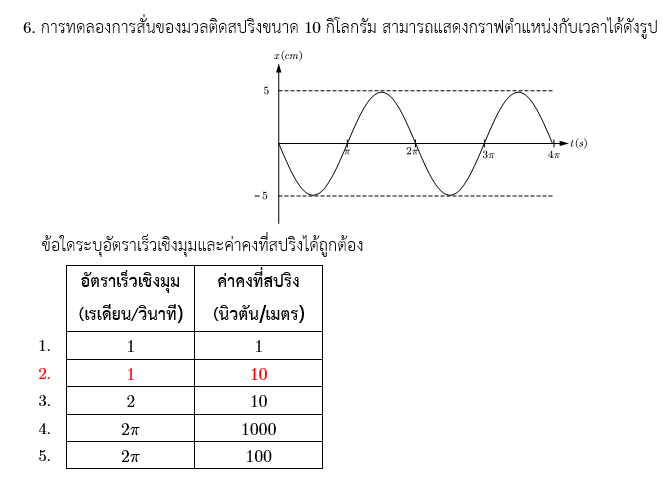

In [16]:
from langchain_core.prompts import ChatPromptTemplate

agent1 = create_agent(
    model=ChatOllama(model="qwen3.5:397b-cloud", temperature=0.3),
    tools=[],  # Add your tools here
    system_prompt="""You are an expert high school physics tutor. 
    When given an image of a physics problem or assignment:
    1. Carefully analyze all visual elements (diagrams, graphs, equations, figures)
    2. Identify the physics concepts and topics involved
    3. Extract all given information, variables, and unknowns
    4. Provide a clear, step-by-step solution
    5. Explain the physics principles used
    6. Show all calculations with proper units
    7. State the final answer clearly
    8. Anwer with thai language only
    9. this system is design for read image and answer with understanding for user question about image.
    Use clear formatting with sections for: Problem Understanding, Given Information, Physics Concepts, Cognitive Errors.""",
    checkpointer=InMemorySaver(),  # Handles conversation memory
)

prompt = ChatPromptTemplate.from_messages([
    ("user", [
        {"type": "text", "text": "{question}"},
        {"type": "image_url", "image_url": {"url": "data:image/png;base64,{image_data}"}}
    ])
])

formatted_messages = prompt.format_messages(
    question="อธิบายมโนทัศน์ในการเรียนรู้ของโจทย์ที่อยู่ในรูป และถ้านักเรียนตอบผิดแสดงความเข้าใจผิดอย่างไรได้บ้า่ง",
    image_data=encode_image_to_base64("image.png")
)

response = agent1.invoke(
    {"messages": formatted_messages},
    {"configurable": {"thread_id": "teacher_2"}}
)

print(response)